<a href="https://colab.research.google.com/github/erdilix/nma-compneu2026/blob/main/projects/behavior_and_theory/laquitaine_motion_prior_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Study Laquitaine & Gardner motion direction prior learning

author: steeve.laquitaine@epfl.ch

Inpired from [Laquitaine & Gardner, Neuron, 2017](https://www.cell.com/neuron/fulltext/S0896-6273(17)31134-0?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627317311340%3Fshowall%3Dtrue)

Purpose: show how subjects could compute a state prediction error signal and use it to learn the motion directions generative process. We chose a Gaussian generative process for simplicity. Circular distributions like Von Mises distributions are more appropriate for a circular space.






In [1]:
# @title Dependencies
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import rcParams
import numpy as np
import os
import numpy as np
from scipy.stats import norm, uniform
import copy

In [2]:
# @title Figure settings
rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

In [3]:
# @title Utils
def build_generative_model(std, mean):
    """create hidden generative process for motion direction
    the experimental Gaussian prior
    """
    # set direction state space
    x = np.arange(1, 360, 1)

    # calculate probability distribution
    pdf = norm.pdf(x, loc=mean, scale=std)
    pdf /= sum(pdf)
    return pdf

def generate_directions(mean, std, n_trials, seed):
    return np.round(norm.rvs(loc=mean, scale=std, size=n_trials, random_state=seed))


def learn_generative_process(motion_directions, learning_rate, x, n_trials):
    """learn the generative process
    """
    # set subject initial belief state
    initial_prior = uniform.pdf(x, loc=x[0], scale=x[-1])
    initial_prior /= sum(initial_prior)
    prior = copy.copy(initial_prior)
    observed = np.zeros((len(x)))
    prediction_errors = []
    priors = []

    for old_trial in range(0, n_trials):

        # locate the observed state component
        state_loc = np.where(x == int(motion_directions[old_trial]))[0][0]

        # compute its state prediction error
        state_pred_error = learning_rate * (1 - prior[state_loc])

        # use the prediction error to update the state belief
        prior[state_loc] = prior[state_loc] + state_pred_error
        prior /= sum(prior)

        # tape
        prediction_errors.append(state_pred_error)
        priors.append(copy.copy(prior))
    return priors

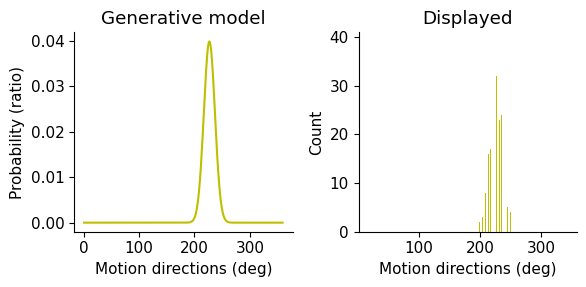

In [4]:
# @title Create first generative process (10 deg prior)
# set generative model parameters
MEAN = 227
STD = 10
N_TRIALS = 800
SEED = 0

# build generative model
x = np.arange(1, 360, 1)
pdf = build_generative_model(STD, MEAN)

# generate directions
directions_prior01 = generate_directions(mean=MEAN, std=STD, n_trials=N_TRIALS, seed=SEED)

# plot the generative process
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(6,3));
ax1.plot(x, pdf, color=[0.75, 0.75, 0]);
ax1.set_title("Generative model");
ax1.set_ylabel("Probability (ratio)");
ax1.set_xlabel("Motion directions (deg)");

# plot generated motion direction distribution
ax2.hist(directions_prior01, color=[0.75, 0.75, 0], bins=180);
ax2.set_title("Displayed");
ax2.set_xlim([x[0], x[-1]]);
ax2.set_ylabel("Count");
ax2.set_xlabel("Motion directions (deg)");

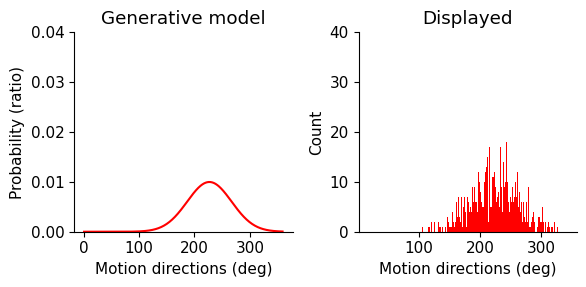

In [5]:
# @title Create second generative process (40 deg prior)
# set generative model parameters
MEAN = 227
STD = 40
N_TRIALS = 800
SEED = 0

# build generative model
x = np.arange(1, 360, 1)
pdf = build_generative_model(STD, MEAN)

# generate directions
directions_prior02 = generate_directions(mean=MEAN, std=STD, n_trials=N_TRIALS, seed=SEED)

# plot the generative process
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(6,3));
ax1.plot(x, pdf, color=[1, 0, 0]);
ax1.set_ylim([0, 0.04]);
ax1.set_title("Generative model");
ax1.set_ylabel("Probability (ratio)");
ax1.set_xlabel("Motion directions (deg)");

# plot generated motion direction distribution
ax2.hist(directions_prior02, color=[1, 0, 0], bins=180);
ax2.set_ylim([0, 40]);
ax2.set_title("Displayed");
ax2.set_xlim([x[0], x[-1]]);
ax2.set_ylabel("Count");
ax2.set_xlabel("Motion directions (deg)");

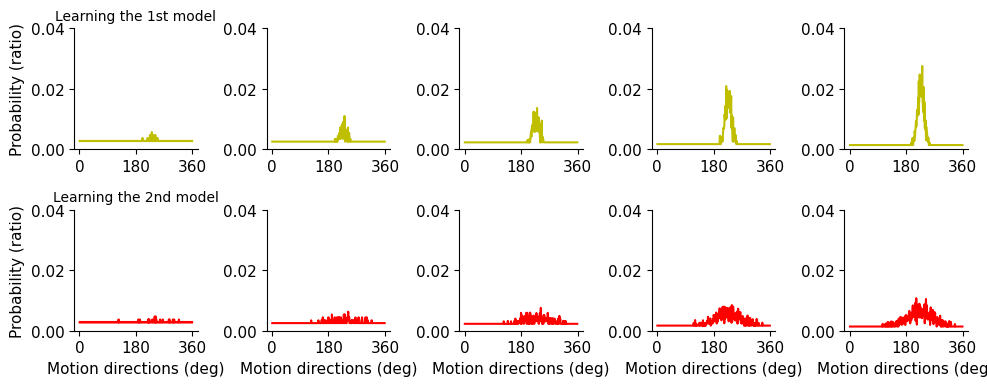

In [6]:
# @title Prior learning with a state prediction error (SPE)

# create initial prior
initial_prior = uniform.pdf(x, loc=x[0], scale=x[-1])
initial_prior /= sum(initial_prior)

# learn model 1
priors01 = learn_generative_process(directions_prior01, learning_rate=0.001, x=x, n_trials=800)

# learn model 2
priors02 = learn_generative_process(directions_prior02, learning_rate=0.001, x=x, n_trials=800)

# figure
steps = [20, 100, 200, 500, 700]
fig, axes = plt.subplots(2,len(steps), figsize=(10,4))

# plot model 1
axes[0,0].plot(x, initial_prior, color=[0.75, 0.75, 0]);
for ix, step in enumerate(steps):
  axes[0,ix].plot(x, priors01[step], color=[0.75, 0.75, 0]);
  axes[0,ix].set_xticks([0, 180, 360])
  axes[0,ix].set_xticklabels([0, 180, 360])
  axes[0,ix].set_ylim([0, 0.04])
  axes[0,0].set_title("Learning the 1st model", fontsize=10)
  if ix==0:
    axes[0,0].set_ylabel("Probability (ratio)")

# plot model 2
axes[1,0].plot(x, initial_prior, color= [1,0,0]);
for ix, step in enumerate(steps):
  axes[1,ix].plot(x, priors02[step], color= [1,0,0]);
  axes[1,ix].set_xticks([0, 180, 360])
  axes[1,ix].set_xticklabels([0, 180, 360])
  axes[1,ix].set_xlabel("Motion directions (deg)")
  axes[1,ix].set_ylim([0, 0.04])
  axes[1,0].set_title("Learning the 2nd model", fontsize=10)
  if ix==0:
    axes[1,0].set_ylabel("Probability (ratio)")
plt.tight_layout()

1. State prediction error (SPE) signal

The learning engine. In cell 4:
state_pred_error = learning_rate * (1 - prior[state_loc])
prior[state_loc] = prior[state_loc] + state_pred_error
prior /= sum(prior)
Each trial: subject sees a motion direction. SPE = how surprising it was = (1 − current belief at that direction). Belief already high there → small error. Belief low (unexpected) → big error. Scale by learning_rate, nudge belief up at that direction, renormalize.

Over 800 trials the flat starting belief morphs into the true distribution (cell 7 shows it converging). Classic delta rule / Rescorla-Wagner update — the same prediction-error learning the brain's dopamine system is thought to use.
→ W2D5/W3D4 ReinforcementLearning (prediction errors, learning rate, TD learning). Learning-rate fitting also touches W1D2 ModelFitting.

2. Motion direction generative process

The hidden truth that spits out stimuli. Cell 4–5:
pdf = norm.pdf(x, loc=mean, scale=std)   # the generative model
directions = norm.rvs(loc=mean, scale=std, ...)  # samples from it
= a Gaussian at 227° (std 10° or 40°) that the experiment secretly draws each trial's direction from. Subject never told it — must learn it via SPE (concept 1). "Generative" = a model of how the data is produced, opposite of just fitting outputs.
→ concept introduced W1D1 ModelTypes (what/how/why, generative vs descriptive models); used heavily in Bayesian framing W3D2 BayesianDecisions.

3. Circular distribution

Directions live on a circle: 359° and 1° are neighbors, not far apart. A normal Gaussian lives on a straight line and doesn't wrap — the notebook admits this in cell 1 ("We chose a Gaussian... for simplicity. Circular distributions... are more appropriate"). Circular distributions handle the wraparound correctly (mean/variance computed on the circle, like the get_cartesian_to_deg circular-stats code you saw in the other notebook).
→ W3D2 BayesianDecisions (Bayesian estimation over circular stimulus features — this Laquitaine content is the behavior/Bayesian project).

4. Von Mises distribution

The circular version of a Gaussian. Bell-shaped but wraps around the circle. Two params:
- μ = mean direction (peak, e.g. 225°)
- κ (kappa) = concentration = how tight (high κ = narrow, like small variance; κ=0 = flat/uniform)

The real paper uses von Mises for both prior and likelihood (κ_p, κ_e from the switching-observer notes). The notebook fakes it with a Gaussian to keep the demo simple.
→ W3D2 BayesianDecisions (same day — it's the circular distribution you'd use for the priors/likelihoods).

---Quick map

┌────────────────────────┬───────────────────────────────────────────────────────────────┐
│        Concept         │                      Where you learn it                       │
├────────────────────────┼───────────────────────────────────────────────────────────────┤
│ State prediction error │ W3D4 ReinforcementLearning (+ W1D2 for learning rate/fitting) │
├────────────────────────┼───────────────────────────────────────────────────────────────┤
│ Generative process     │ W1D1 ModelTypes → deepened W3D2 BayesianDecisions             │
├────────────────────────┼───────────────────────────────────────────────────────────────┤
│ Circular distribution  │ W3D2 BayesianDecisions                                        │
├────────────────────────┼───────────────────────────────────────────────────────────────┤
│ Von Mises              │ W3D2 BayesianDecisions                                        │
└────────────────────────┴───────────────────────────────────────────────────────────────┘

Bottom line: this notebook is a preview mash-up — it borrows the prediction-error learning idea (RL week) to teach a subject the generative prior (Model Types → Bayesian week), and flags that proper circular math (von Mises, W3D2 Bayesian) is the real tool. The single most relevant day is W3D2 BayesianDecisions; the learning mechanism itself is W3D4 ReinforcementLearning.

4 แนวคิด (ภาษาไทย)

1. State prediction error (SPE) — สัญญาณข้อผิดพลาดการทำนาย

เครื่องยนต์การเรียนรู้. cell 4:
state_pred_error = learning_rate * (1 - prior[state_loc])
prior[state_loc] = prior[state_loc] + state_pred_error
prior /= sum(prior)
แต่ละ trial คนเห็นทิศการเคลื่อนที่. SPE = เซอร์ไพรส์แค่ไหน = (1 − ความเชื่อปัจจุบันที่ทิศนั้น).
- เชื่ออยู่แล้วว่าทิศนี้มาบ่อย → error เล็ก
- ไม่คาดคิด → error ใหญ่

เอา error คูณ learning_rate → ดันความเ 800 trial → ความเชื่อจากแบนราบค่อยๆกลายเป็น distribution จริง (cell 7 โชว์การลู่เข้า).

= delta rule / Rescorla-Wagner แบบเดี
→ เรียนที่ W3D4 ReinforcementLearning (prediction error, learning rate, TD learning). ส่วน fit learning rate แตะ W1D2 ModelFitting.

2. Motion direction generative process — กระบวนการสร้างข้อมูล

ความจริงที่ซ่อนอยู่ ที่ผลิตสิ่งเร้าออกมา. cell 4–5:
pdf = norm.pdf(x, loc=mean, scale=st
directions = norm.rvs(loc=mean, scale=std, ...)  # สุ่มจากมัน
= Gaussian ที่ 227° (std 10° หรือ 40°) กมา. คนไม่รู้ค่านี้ ต้องเรียนเองผ่าน SPE (ข้อ1). "Generative" = โมเดลว่าข้อมูลถูกผลิตยังไง ตรงข้ามกับแค่ fit ผลลัพธ์.
→ แนวคิดเริ่มที่ W1D1 ModelTypes (what/how/why, generative vs descriptive); ใช้หนักในกรอบ Bayesian ที่ W3D2 BayesianDecisions.

3. Circular distribution — การแจกแจงเชิงวงกลม

ทิศทางอยู่บนวงกลม: 359° กับ 1° ติดกัน ไม่ได้ ไม่วนรอบ — โน้ตบุ๊คยอมรับใน cell 1 ("เลือก Gaussian เพื่อความง่าย... circular distribution เหมาะกว่า"). Circular distribution จัดการการวนรอบถูกต้อง (คำนวณ mean/variance บนวงกลม เหมือนโค้ด get_cartesian_to_deg ในโน้ตบุ๊คก่อนหน้า).
→ W3D2 BayesianDecisions (Bayesian estimation บนสิ่งเร้าเชิงวงกลม — เนื้อหา Laquitaine นี้คือ project นั้นเอง).

4. Von Mises distribution

= Gaussian เวอร์ชันวงกลม. รูประฆังแต่วนรอ
- μ = ทิศเฉลี่ย (ยอด, เช่น 225°)
- κ (kappa) = ความเข้มข้น = แคบแค่ไหน (κ สูง = แคบ, เหมือน variance เล็ก; κ=0 = แบนราบ/uniform)

เปเปอร์จริงใช้ von Mises ทั้ง prior และ likelihood (κ_p, κ_e จากโน้ต switching observer). โน้ตบุ๊คปลอมด้วย Gaussian เพื่อความง่าย.
→ W3D2 BayesianDecisions (วันเดียวกัน — เป็น distribution วงกลมที่ใช้ทำ prior/likelihood).

---ตารางสรุป

┌────────────────────────┬──────────────────────────┐
│         แนวคิด          │                       เรียนที่ไหน                        │
├────────────────────────┼──────────────────────────┤
│ State prediction error │ W3D4 ReinforcementLearning (+ W1D2 fit learning rate) │
├────────────────────────┼───────────────────────────────────────────────────────┤
│ Generative process     │ W1D1 ModelTypes → ลึกที่ W3D2 BayesianDecisions          │
├────────────────────────┼───────────────────────────────────────────────────────┤
│ Circular distribution  │ W3D2 BayesianDecisions                                │
├────────────────────────┼──────────────────────────┤│ Von Mises              │ W3D2 Baye                │
└────────────────────────┴───────────────────────────────────────────────────────┘

สรุป: โน้ตบุ๊คนี้เป็น preview ผสม — ยืมไอเดีย prediction-error learning (สัปดาห์ RL) มาสอน subject ให้เรียน generative prior (Model Types → Bayercular math (von Mises, W3D2).วันที่เกี่ยวสุด = W3D2 BayesianDecisions; กลไกการเรียนรู้ = W3D4 ReinforcementLearning.